In [1]:
# ============================================================
# Google Colab setup + automatic Excel file upload
# ============================================================

!pip -q install openpyxl seaborn scikit-learn pandas matplotlib numpy

from google.colab import files
from pathlib import Path
import os

print("Please upload: mltak1Data.xlsx")
uploaded = files.upload()

if 'mltak1Data.xlsx' in uploaded:
    DATA_FILE = 'mltak1Data.xlsx'
elif len(uploaded) == 1:
    DATA_FILE = next(iter(uploaded.keys()))
    print(f"Using uploaded file: {DATA_FILE}")
else:
    raise FileNotFoundError("Please upload the Excel file mltak1Data.xlsx")

OUTPUT_DIR = Path('/content/mltak_outputs')
FIG_DIR = OUTPUT_DIR / 'figures'
TABLE_DIR = OUTPUT_DIR / 'tables'
TEXT_DIR = OUTPUT_DIR / 'text_results'
for d in [OUTPUT_DIR, FIG_DIR, TABLE_DIR, TEXT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Input file: {DATA_FILE}")
print(f"Output directory: {OUTPUT_DIR}")

Please upload: mltak1Data.xlsx


Saving mltak1Data.xlsx to mltak1Data.xlsx
Input file: mltak1Data.xlsx
Output directory: /content/mltak_outputs


In [2]:
# ============================================================
# PART 1 — Linear Regression
# Original code preserved, with Colab-compatible file handling
# ============================================================

import openpyxl as py
import sklearn
import pandas as pd
from sklearn.linear_model import LinearRegression
#import xlrd as xl

df = pd.read_excel(DATA_FILE)
#print(df)
#print("\n\n\n\n\n\n\n\n")
df_2 = df.drop(['total', 'pass', 'name'], axis=1)
#print("deleted columns\n\n\n\n\n\n\n\n")
#loc = ("mltak1Data.xlsx")  # Giving the location of the file

#wb = xl.open_workbook(loc)  # opening & reading the excel file
#s1 = wb.sheet_by_index(0)
#print(df_2)

cols_df = len(df.axes[1])
cols_df_2=len(df_2.axes[1])

#print(cols)
#print(cols_df_2)

yout = df['total']

model = LinearRegression()
model.fit(df_2, yout)

col_names = df_2.columns.values.tolist()

coefs = list(model.coef_)
for i in range(cols_df_2):
    print(col_names[i], "Column's Coefficient:\n", coefs[i])
print('w0 Coefficient:', model.intercept_)

# Added export of the same numerical results
linear_regression_results = pd.DataFrame({
    'Feature': col_names,
    'Coefficient': coefs
})
linear_regression_results.loc[len(linear_regression_results)] = ['w0_intercept', model.intercept_]
linear_regression_results.to_csv(TABLE_DIR / '01_linear_regression_coefficients.csv', index=False)
linear_regression_results.to_excel(TABLE_DIR / '01_linear_regression_coefficients.xlsx', index=False)

search Column's Coefficient:
 0.14999999999999974
tak3 Column's Coefficient:
 0.08333333333333348
tak2 Column's Coefficient:
 0.08333333333333305
tak1 Column's Coefficient:
 0.08333333333333331
final Column's Coefficient:
 0.6000000000000001
midterm Column's Coefficient:
 0.5999999999999998
w0 Coefficient: 8.881784197001252e-15


Ridge Classifier Section:
----------------------------------------------
[ 0.04054112  0.00988552  0.00629097 -0.01244292  0.12161607  0.14147939]
Accuracy: 1.0
Precision: 1.0
Confusion Matrix:
 [[ 4  0]
 [ 0 17]]
[-1.92813372]


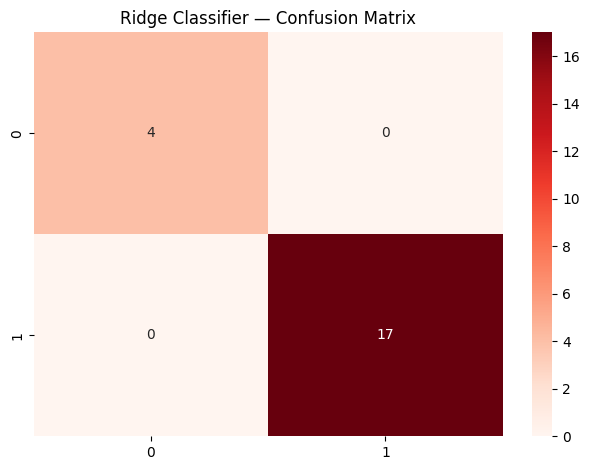


SGD Classifier Section:
---------------------------------------------
[[ -52.74207369  312.76778063 -149.10025707 -313.62467866  367.18080548
   335.90402742]]
Accuracy: 0.8571428571428571
Precision: 1.0
Confusion Matrix:
 [[ 4  0]
 [ 3 14]]
[-18.20149781]


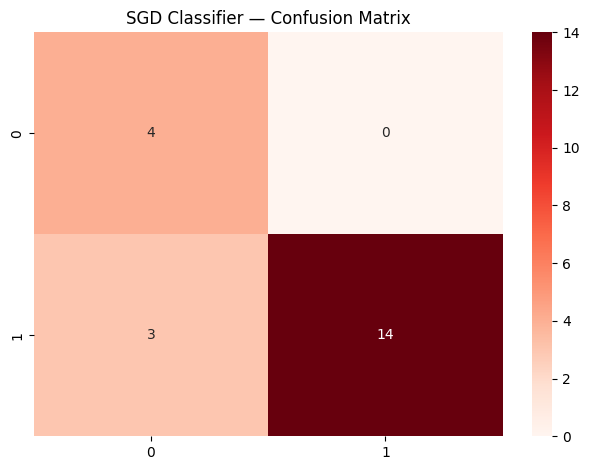


Logistic regression  Section:
---------------------------------------------
[[0.34382724 0.12458579 0.15419427 0.01134717 0.87991745 0.96688552]]
Accuracy: 1.0
Precision: 1.0
Confusion Matrix:
 [[ 4  0]
 [ 0 17]]
[-19.28770683]


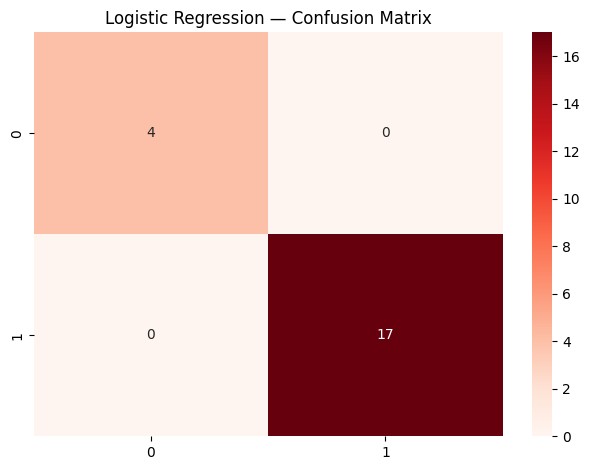

In [3]:
# ============================================================
# PART 2 — Ridge Classifier, SGD Classifier, Logistic Regression
# ============================================================

import openpyxl
import matplotlib.pyplot as plt

import sklearn
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LinearRegression, LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix
from matplotlib import pyplot

df = pd.read_excel(DATA_FILE)
df_2 = df.drop(['total', 'pass', 'name'], axis=1)
t = []
for i in df['pass']:
    if i == 'no':
        t.append(0)

    else:
        t.append(1)
#print(t)

classifier_results = []

# Ridge Classifier
model = RidgeClassifier()
model.fit(df_2, t)

y = model.predict(df_2)
print('Ridge Classifier Section:\n----------------------------------------------')
print(model.coef_)
print('Accuracy:', accuracy_score(y_true=t, y_pred=y))
print('Precision:', precision_score(y_true=t, y_pred=y))
print('Confusion Matrix:\n', confusion_matrix(y_true=t, y_pred=y))

print(model.intercept_)
cm=confusion_matrix(y_true=t,y_pred=y)

classifier_results.append({
    'Classifier': 'Ridge Classifier',
    'Accuracy': accuracy_score(y_true=t, y_pred=y),
    'Precision': precision_score(y_true=t, y_pred=y),
    'Intercept': model.intercept_[0] if hasattr(model.intercept_, '__len__') else model.intercept_
})

plt.figure()
sns.heatmap(cm,cmap="Reds", annot=True, fmt='g')
plt.title('Ridge Classifier — Confusion Matrix')
plt.tight_layout()
plt.savefig(FIG_DIR / '02_ridge_classifier_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
pd.DataFrame(cm).to_csv(TABLE_DIR / '02_ridge_classifier_confusion_matrix.csv', index=False)

# SGD Classifier
model = SGDClassifier()
model.fit(df_2, t)

y = model.predict(df_2)
print("\nSGD Classifier Section:\n---------------------------------------------")
print(model.coef_)
print('Accuracy:', accuracy_score(y_true=t, y_pred=y))
print('Precision:', precision_score(y_true=t, y_pred=y))
print('Confusion Matrix:\n', confusion_matrix(y_true=t, y_pred=y))
print(model.intercept_)
cm=confusion_matrix(y_true=t,y_pred=y)

classifier_results.append({
    'Classifier': 'SGD Classifier',
    'Accuracy': accuracy_score(y_true=t, y_pred=y),
    'Precision': precision_score(y_true=t, y_pred=y),
    'Intercept': model.intercept_[0] if hasattr(model.intercept_, '__len__') else model.intercept_
})

plt.figure()
sns.heatmap(cm,cmap="Reds", annot=True, fmt='g')
plt.title('SGD Classifier — Confusion Matrix')
plt.tight_layout()
plt.savefig(FIG_DIR / '03_sgd_classifier_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
pd.DataFrame(cm).to_csv(TABLE_DIR / '03_sgd_classifier_confusion_matrix.csv', index=False)

# Logistic Regression
model = LogisticRegression()
model.fit(df_2, t)

y = model.predict(df_2)
print("\nLogistic regression  Section:\n---------------------------------------------")

print(model.coef_)
print('Accuracy:', accuracy_score(y_true=t, y_pred=y))
print('Precision:', precision_score(y_true=t, y_pred=y))
print('Confusion Matrix:\n', confusion_matrix(y_true=t, y_pred=y))
print(model.intercept_)

cm=confusion_matrix(y_true=t,y_pred=y)
classifier_results.append({
    'Classifier': 'Logistic Regression',
    'Accuracy': accuracy_score(y_true=t, y_pred=y),
    'Precision': precision_score(y_true=t, y_pred=y),
    'Intercept': model.intercept_[0] if hasattr(model.intercept_, '__len__') else model.intercept_
})

plt.figure()
sns.heatmap(cm,cmap="Reds", annot=True, fmt='g')
plt.title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.savefig(FIG_DIR / '04_logistic_regression_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
pd.DataFrame(cm).to_csv(TABLE_DIR / '04_logistic_regression_confusion_matrix.csv', index=False)

# Save combined classifier summary
classifier_summary = pd.DataFrame(classifier_results)
classifier_summary.to_csv(TABLE_DIR / '05_classifier_summary.csv', index=False)
classifier_summary.to_excel(TABLE_DIR / '05_classifier_summary.xlsx', index=False)

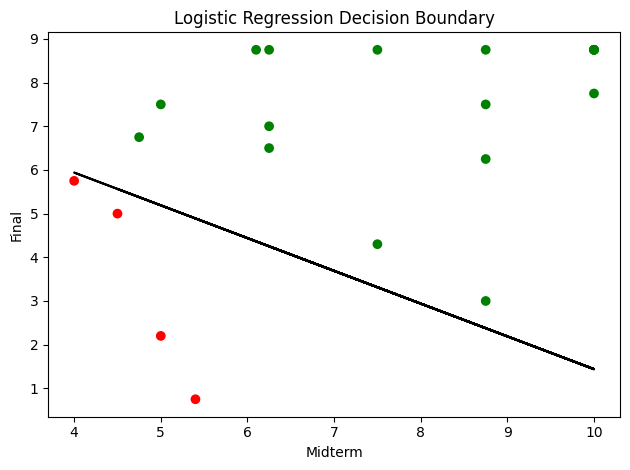

In [4]:
# ============================================================
# PART 3 — Logistic Regression decision boundary (midterm/final)
# ============================================================

import openpyxl
import matplotlib.pyplot as plt

import sklearn
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LinearRegression, LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix
from matplotlib import pyplot

df = pd.read_excel(DATA_FILE)
y = df['pass']

# Logistic Regression
model = LogisticRegression()
X2 = df[['midterm', 'final']]
model.fit(X2, y)

color=[]
for i in df['pass']:
    if i == 'no':
        color.append('red')
    else:
        color.append('green')

x1 = df['midterm']
x2 = df['final']
#print(-model.intercept_/model.coef_[0][0])
plt.figure()
plt.scatter(x1, x2, c=color)

#op1=model.intercept_[0]/model.coef_[0][0]
#op2=model.intercept_[1]/model.coef_[0][0]
#op3=model.intercept_[2]/model.coef_[0][0]

#d=op1+op2+op3
#print(model.intercept_)
#print(model.coef_[0][0])
#d4=-model.coef_[0][0]/model.intercept_[1]
#print(d)



#plt.plot(x1, -x1*model.coef_[0][1]*model.intercept_[1]/model.coef_[0][0]/model.coef_[0][0]+-model.intercept_[2]+model.intercept_[1]/model.coef_[0][0], c='black')

plt.plot(x1, -model.intercept_/model.coef_[0][0]-x1*model.coef_[0][1]/model.coef_[0][0], c='black')

#plt.plot(x1, -x1*model.coef_[0][1]/model.coef_[0][0], c='black')
plt.xlabel('Midterm')
plt.ylabel('Final')
plt.title('Logistic Regression Decision Boundary')
plt.tight_layout()
plt.savefig(FIG_DIR / '06_logistic_regression_decision_boundary.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

pd.DataFrame({
    'Parameter': ['intercept', 'coef_midterm', 'coef_final'],
    'Value': [model.intercept_[0], model.coef_[0][0], model.coef_[0][1]]
}).to_csv(TABLE_DIR / '06_logistic_decision_boundary_parameters.csv', index=False)

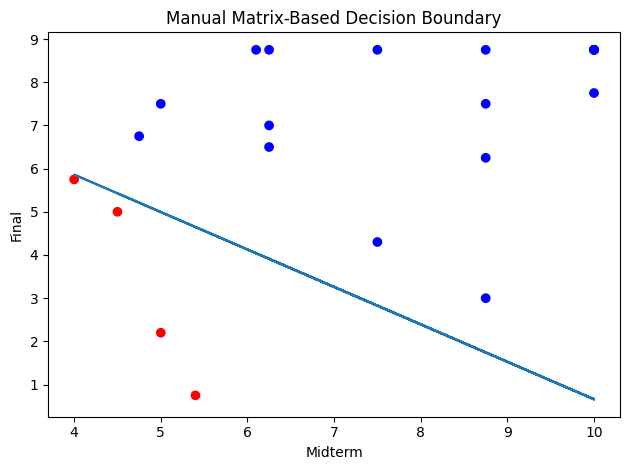

Manual matrix weights:
w0 = 1.5664074079610102
w1 = -0.14555444554973856
w2 = -0.16792832923562465


In [5]:
# ============================================================
# PART 4 — Manual matrix-based calculation of the classifier
# ============================================================

import openpyxl
import matplotlib.pyplot as plt

import sklearn
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LinearRegression, LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix
from matplotlib import pyplot
import numpy as np

df = pd.read_excel(DATA_FILE)

X2 = df[['midterm', 'final']].values.tolist()

for i in range(len(X2)):
    X2[i].insert(0, 1)

X2 = np.array(X2)
#print(X2)

X2_trans = X2.transpose()
#print(X2_trans)



X_inverse_mul = np.linalg.inv(np.matmul(X2_trans, X2))
#print(X_inverse_mul)



X_new = np.matmul(X_inverse_mul, X2_trans)

#print(X_new)
t = []
for i in df['pass']:
    t.append([1, 0]) if i == 'yes' else t.append([0, 1])

W = np.matmul(X_new, t)
#print(W)
W_row = W.tolist()

w0 = W_row[0][1] - W_row[0][0]
w1 = W_row[1][1] - W_row[1][0]
w2 = W_row[2][1] - W_row[2][0]
#print(W_row)

colors = []
for i in df['pass']:
    colors.append('red') if i == 'no' else colors.append('blue')

x1 = df['midterm']
x2 = df['final']
plt.figure()
plt.plot(x1, -w0/w2 - w1/w2 * x1)
plt.scatter(x1, x2, c=colors)

plt.xlabel('Midterm')
plt.ylabel('Final')
plt.title('Manual Matrix-Based Decision Boundary')
plt.tight_layout()
plt.savefig(FIG_DIR / '07_manual_matrix_decision_boundary.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

pd.DataFrame({
    'Parameter': ['w0', 'w1', 'w2'],
    'Value': [w0, w1, w2]
}).to_csv(TABLE_DIR / '07_manual_matrix_weights.csv', index=False)
pd.DataFrame(W).to_csv(TABLE_DIR / '07_manual_matrix_W.csv', index=False)

print('Manual matrix weights:')
print('w0 =', w0)
print('w1 =', w1)
print('w2 =', w2)

In [6]:
# ============================================================
# FINAL CELL — Automatically package and download ALL results
# ============================================================

from google.colab import files
import shutil
import os
from pathlib import Path

# Save the original input data inside the output package for reproducibility
try:
    shutil.copy2(DATA_FILE, OUTPUT_DIR / Path(DATA_FILE).name)
except Exception as e:
    print('Could not copy input file:', e)

# Save a plain-text inventory of generated files
inventory_path = TEXT_DIR / 'generated_files.txt'
with open(inventory_path, 'w', encoding='utf-8') as f:
    for path in sorted(OUTPUT_DIR.rglob('*')):
        if path.is_file():
            f.write(str(path.relative_to(OUTPUT_DIR)) + '\n')

# Create a ZIP containing all tables, figures, text results, and the input Excel file
ZIP_BASENAME = '/content/mltak_all_results'
ZIP_PATH = shutil.make_archive(ZIP_BASENAME, 'zip', root_dir=OUTPUT_DIR)

print('All results have been collected.')
print('ZIP file:', ZIP_PATH)
print('Files included:')
for path in sorted(OUTPUT_DIR.rglob('*')):
    if path.is_file():
        print(' -', path.relative_to(OUTPUT_DIR))

# Automatically download the complete package in Google Colab
files.download(ZIP_PATH)

All results have been collected.
ZIP file: /content/mltak_all_results.zip
Files included:
 - figures/02_ridge_classifier_confusion_matrix.png
 - figures/03_sgd_classifier_confusion_matrix.png
 - figures/04_logistic_regression_confusion_matrix.png
 - figures/06_logistic_regression_decision_boundary.png
 - figures/07_manual_matrix_decision_boundary.png
 - mltak1Data.xlsx
 - tables/01_linear_regression_coefficients.csv
 - tables/01_linear_regression_coefficients.xlsx
 - tables/02_ridge_classifier_confusion_matrix.csv
 - tables/03_sgd_classifier_confusion_matrix.csv
 - tables/04_logistic_regression_confusion_matrix.csv
 - tables/05_classifier_summary.csv
 - tables/05_classifier_summary.xlsx
 - tables/06_logistic_decision_boundary_parameters.csv
 - tables/07_manual_matrix_W.csv
 - tables/07_manual_matrix_weights.csv
 - text_results/generated_files.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>